In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from collections import defaultdict
from tqdm import tqdm

In [3]:
from helpers import *

2025-11-24 19:22:55.662 | INFO     | time_series.config:<module>:13 - PROJ_ROOT path is: /home/james/Repo/PhD Repo/time_series_clustering


/home/james/Repo/PhD Repo/time_series_clustering/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Experiment Setup

In [4]:
import os
from datetime import datetime


if not os.path.exists("./sinusoid_full"):
    os.mkdir("./sinusoid_full")

ts = datetime.now().strftime("%Y-%m-%d-%H-%M")

savefile_base = "sinusoid_full/" + ts

os.mkdir(savefile_base)

# Test parameter tuning using estimation error

## Set up

In [4]:
f = lambda x: np.sin(x)

x = np.linspace(-10, 10, 200)
y = f(x)

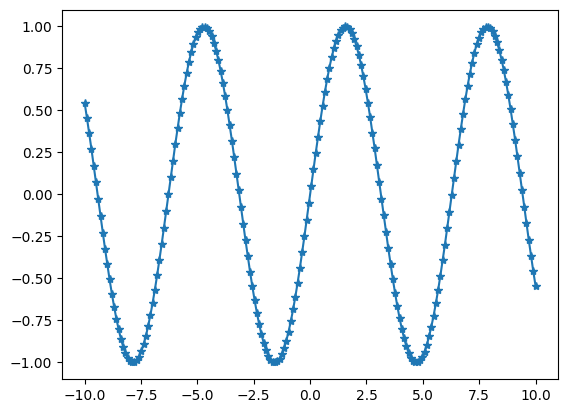

In [5]:
plt.plot(x, y, "-*")

In [ ]:
savefile = savefile_base + "/paramsearch_experiment"
os.mkdir(savefile)

In [ ]:
sigma = 1
N_runs = 100

N_sweep_gridsearch = 20

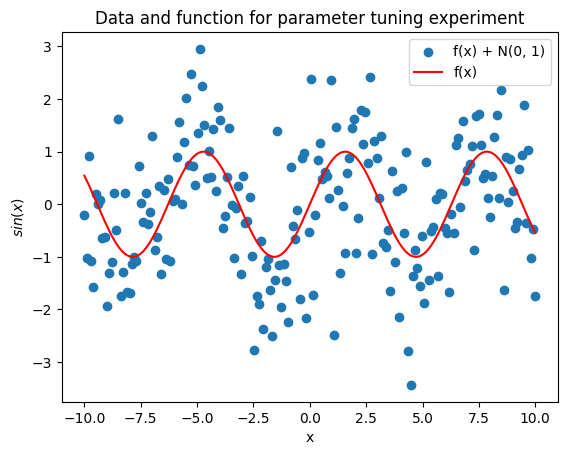

In [7]:
y_data = y + np.random.normal(0, sigma, len(y))

plt.scatter(x, y_data)
plt.plot(x, y, color="red")

plt.xlabel("x")
plt.ylabel("$sin(x)$")
plt.legend(["f(x) + N(0, 1)", "f(x)"], loc="upper right")
plt.title("Data and function for parameter tuning experiment")
plt.savefig(savefile + "/data_setup.png")

In [8]:
results = defaultdict(list)

In [ ]:
paramsearch = GridSearch(
    KRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(0.1, 5, N_sweep_gridsearch),
        reg = np.linspace(1e-9, 1e-2, N_sweep_gridsearch)
    )
)

for i in tqdm(range(N_runs)):
    y_data = y + np.random.normal(0, sigma, len(y))

    paramsearch.fit(x, y_data)

    bandwidth = paramsearch.best_params["bandwidth"]
    reg = paramsearch.best_params["reg"]

    model = KernelRidgeRegression(
        kernels=[GaussianKernel(bandwidth=bandwidth)],
        reg = reg,
        lag = 1
    )

    model.fit(x, y_data)

    y_pred = model.predict(x)

    results["tuning_method"].append("CrossValidation5Fold")
    results["run"].append(i)
    results["bandwidth"].append(bandwidth)
    results["reg"].append(reg)
    results["MSE (Estimation)"].append(mean_squared_error(y_pred, y)) # In sample training error
    results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_data)) # In sample training error

100%|██████████| 100/100 [03:41<00:00,  2.21s/it]


In [ ]:
paramsearch = OptunaHyperparameterTuning(
    KRRWrapper,
    param_grid = dict(
        bandwidth = dict(type="float", min=0.1, max=5),
        reg = dict(type="float", min=1e-9, max=1e-2),
    )
)

for i in tqdm(range(N_runs)):
    y_data = y + np.random.normal(0, sigma, len(y))

    paramsearch.fit(x, y_data)

    bandwidth = paramsearch.best_params["bandwidth"]
    reg = paramsearch.best_params["reg"]

    model = KernelRidgeRegression(
        kernels=[GaussianKernel(bandwidth=bandwidth)],
        reg = reg,
        lag = 1
    )

    model.fit(x, y_data)

    y_pred = model.predict(x)

    results["tuning_method"].append("Optuna5Fold")
    results["run"].append(i)
    results["bandwidth"].append(bandwidth)
    results["reg"].append(reg)
    results["MSE (Estimation)"].append(mean_squared_error(y_pred, y)) # In sample training error
    results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_data)) # In sample training error

100%|██████████| 100/100 [00:24<00:00,  4.05it/s]


In [20]:
df = pd.DataFrame(results)
df.to_csv(savefile + "/Paramtuning_results.csv")

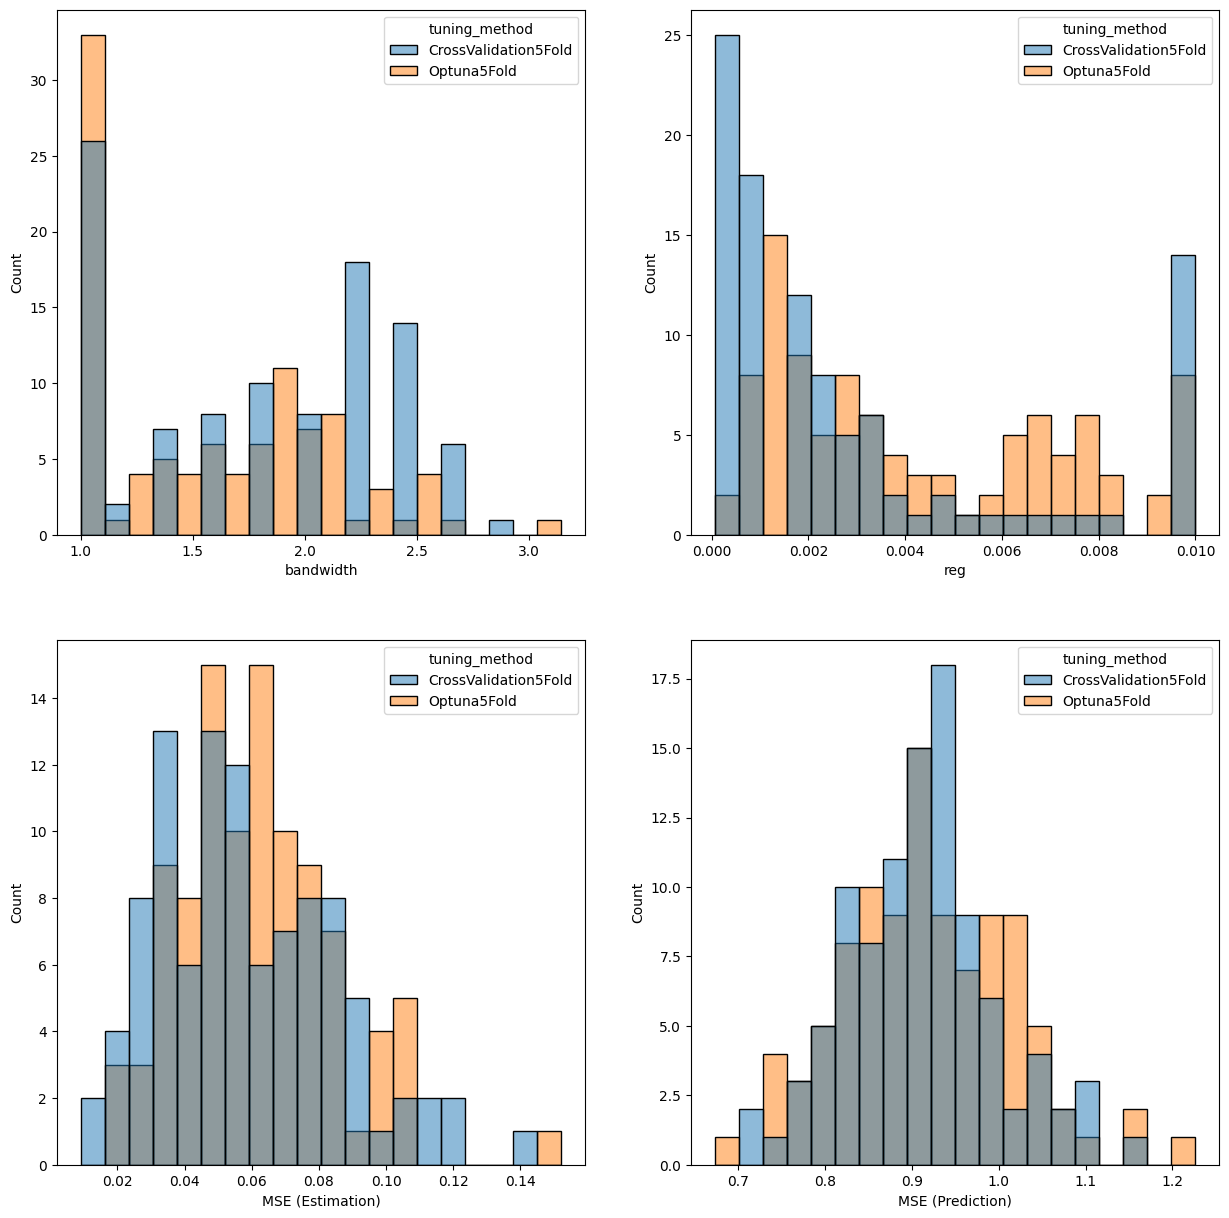

In [21]:
fig, ax = plt.subplots(ncols=2, nrows = 2, figsize=(15, 15))

sns.histplot(df, bins=20, x="bandwidth", ax=ax[0][0], hue="tuning_method")
sns.histplot(df, bins=20, x="reg", ax=ax[0][1], hue="tuning_method")
sns.histplot(df, bins=20, x="MSE (Estimation)", ax=ax[1][0], hue="tuning_method")
sns.histplot(df, bins=20, x="MSE (Prediction)", ax=ax[1][1], hue="tuning_method")

plt.savefig(savefile + "/paramtuning_results.png")

# Test clusering by sweeping frequency

In [20]:
savefile = savefile_base + "/experiment_frequency_sweep"
os.mkdir(savefile)

In [ ]:
frequencies = np.linspace(1e-9, 2, 100)
N_runs = 100
sigma = 1

In [65]:
f = lambda x: np.sin(x)

x = np.linspace(-10, 10, 200)
y = f(x)

## Use same bandwidth

In [ ]:
paramsearch = GridSearch(
    KRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(1, 5, 20),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

y_data = y + np.random.normal(0, sigma, len(y))

paramsearch.fit(x, y_data)

bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

In [9]:
model1 = KernelRidgeRegression(
    kernels=[GaussianKernel(bandwidth=bandwidth)],
    reg = reg,
    lag = 1
)

model1.fit(x, y_data)

In [10]:
results = defaultdict(list)

In [ ]:
ip1 = inner_product(model1, model1)

for freq in tqdm(frequencies):
    temp_results = defaultdict(list)
    paramsearch = GridSearch(
        KRRWrapper,
        param_grid=dict(
            bandwidth=[1],
            reg = np.linspace(1e-9, 1e-2, 20)
        )
    )

    for i in range(N_runs):
        y = f(freq*x)
        y_data = y + np.random.normal(0, sigma, len(y))

        paramsearch.fit(x, y_data)
        reg = paramsearch.best_params["reg"]

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=bandwidth)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y_data)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)

        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred, y))
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

    results["frequency"].append(freq)
    results["experiment"].append("Same Bandwidth")
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

## Use inverse frequency

In [13]:
paramsearch = GridSearch(
    KRRWrapper,
    param_grid=dict(
        bandwidth=[1],
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

In [14]:
paramsearch.fit(x, y_data)
reg = paramsearch.best_params["reg"]

model1 = KernelRidgeRegression(
    kernels=[GaussianKernel(bandwidth=1)],
    reg = reg,
    lag = 1
)

model1.fit(x, y_data)

In [ ]:
ip1 = inner_product(model1, model1)

for freq in tqdm(frequencies):
    temp_results = defaultdict(list)
    paramsearch = GridSearch(
        KRRWrapper,
        param_grid=dict(
            bandwidth=[1/freq],
            reg = np.linspace(1e-9, 1e-2, 20)
        )
    )

    for i in range(N_runs):
        y = f(freq*x)
        y_data = y + np.random.normal(0, sigma, len(y))


        paramsearch.fit(x, y_data)
        reg = paramsearch.best_params["reg"]

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=1/freq)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y_data)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)

        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred, y))
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))
        
    results["frequency"].append(freq)
    results["experiment"].append("Inverse Freq")
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

## Use param tuning

In [16]:
paramsearch = GridSearch(
    KRRWrapper,
    param_grid=dict(
        bandwidth=np.linspace(1, 5, 20),
        reg = np.linspace(1e-9, 1e-2, 20)
    )
)

y_data = y + np.random.normal(0, 1, len(y))

paramsearch.fit(x, y_data)

bandwidth = paramsearch.best_params["bandwidth"]
reg = paramsearch.best_params["reg"]

In [17]:
model1 = KernelRidgeRegression(
    kernels=[GaussianKernel(bandwidth=bandwidth)],
    reg = reg,
    lag = 1
)

model1.fit(x, y_data)

In [18]:
ip1 = inner_product(model1, model1)

for freq in tqdm(frequencies):
    temp_results = defaultdict(list)
    paramsearch = GridSearch(
        KRRWrapper,
        param_grid=dict(
            bandwidth=np.linspace(1, 5, 20),
            reg = np.linspace(1e-9, 1e-2, 20)
        )
    )

    for i in range(N_runs):
        y = f(freq*x)
        y_data = y + np.random.normal(0, 1, len(x))

        paramsearch.fit(x, y_data)
        bandwidth = paramsearch.best_params["bandwidth"]
        reg = paramsearch.best_params["reg"]

        model = KernelRidgeRegression(
            kernels=[
                GaussianKernel(bandwidth=1/freq)
            ],
            reg = reg,
            lag=1
        )

        model.fit(x, y_data)
        y_pred = model.predict(x)

        ip2 = inner_product(model, model)
        ip12 = inner_product(model1, model)

        temp_results["MSE (Estimation)"].append(mean_squared_error(y_pred, y))
        temp_results["MSE (Prediction)"].append(mean_squared_error(y_pred, y_data))
    
        temp_results["ip1"].append(ip1)
        temp_results["ip2"].append(ip2)
        temp_results["ip12"].append(ip12)

        temp_results["dist"].append(ip1 + ip2 - 2*ip12)
        temp_results["cosine"].append(ip12/np.sqrt(ip1*ip2))

    results["experiment"].append("Tune Bandwidth")
    results["frequency"].append(freq)
    for k, v in temp_results.items():
        results[k].append(np.mean(v))

In [21]:
df = pd.DataFrame(results)
df.to_csv(savefile + "/frequency_sweep.csv")

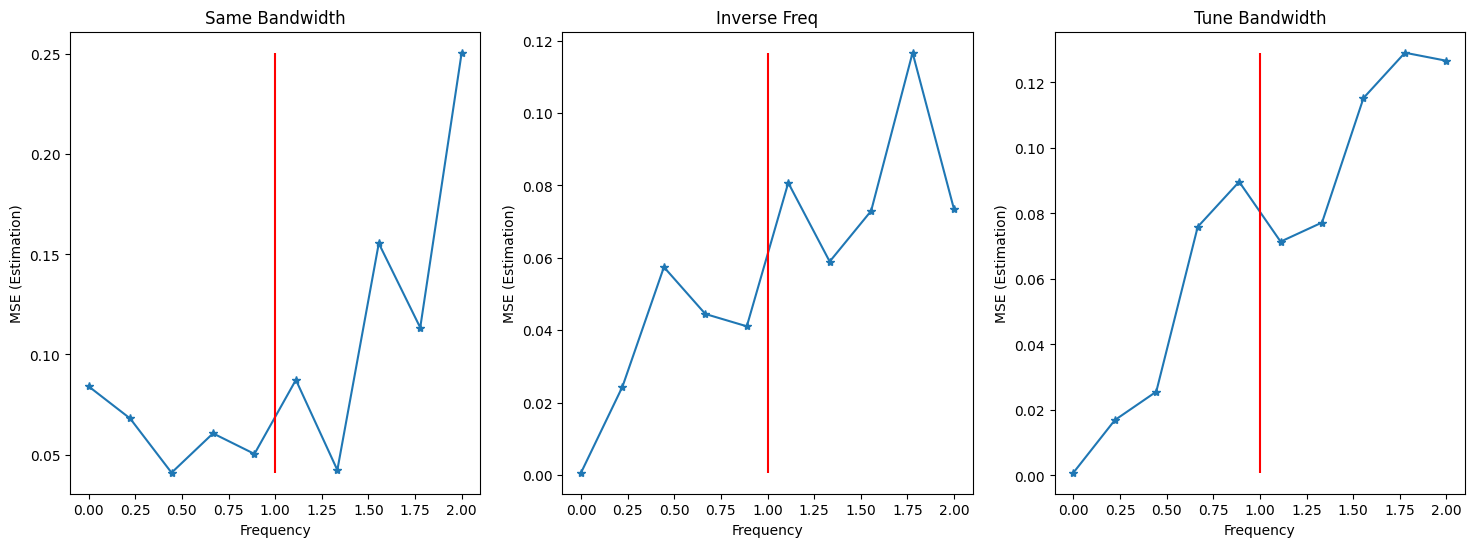

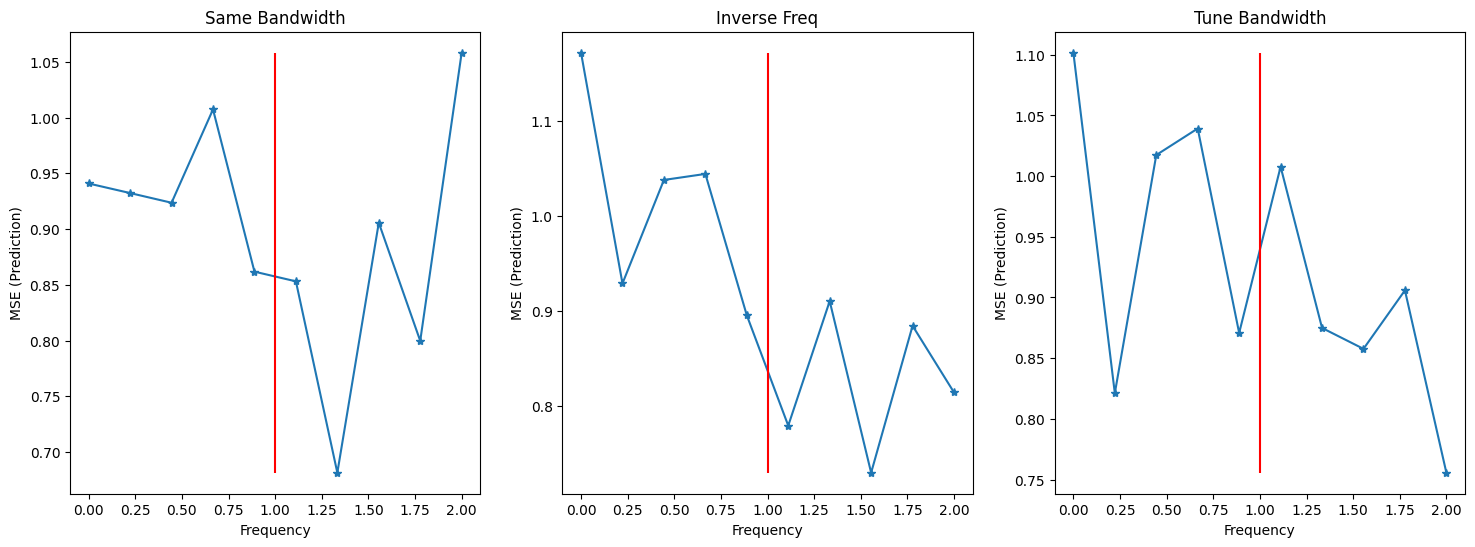

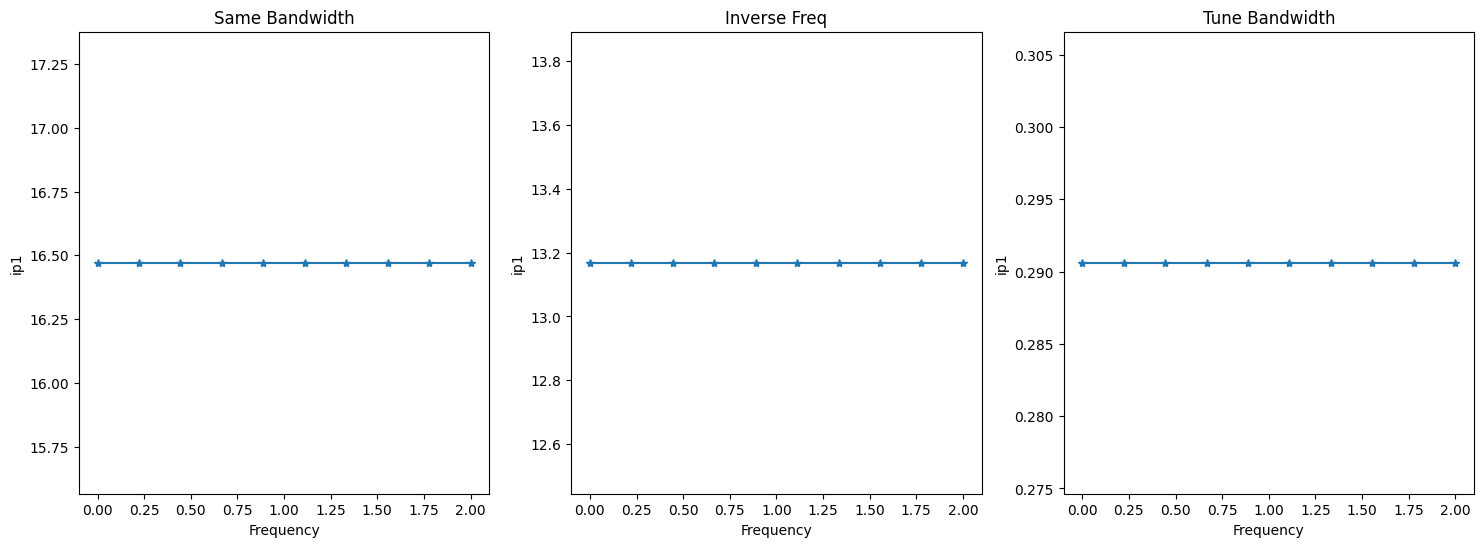

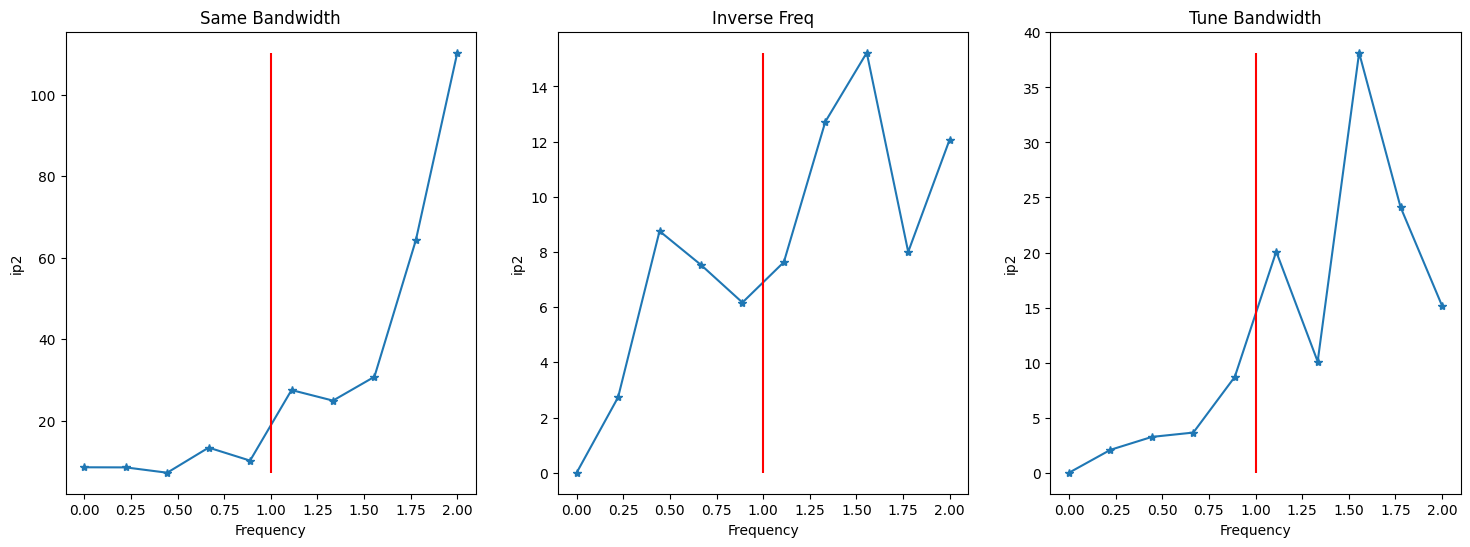

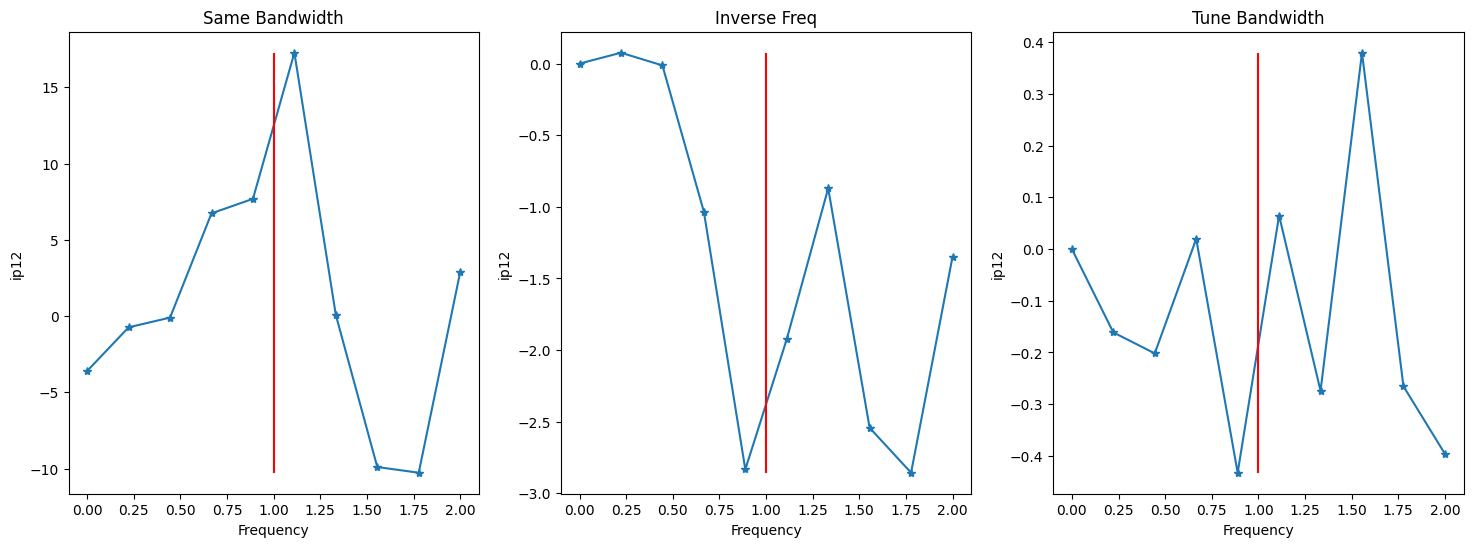

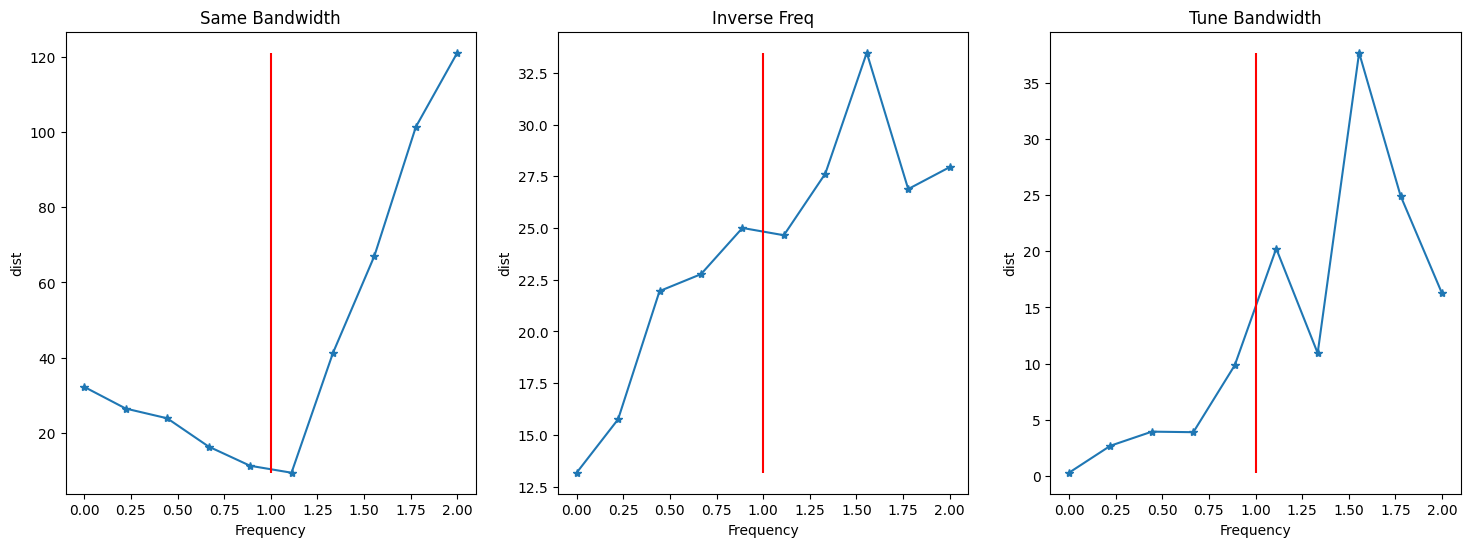

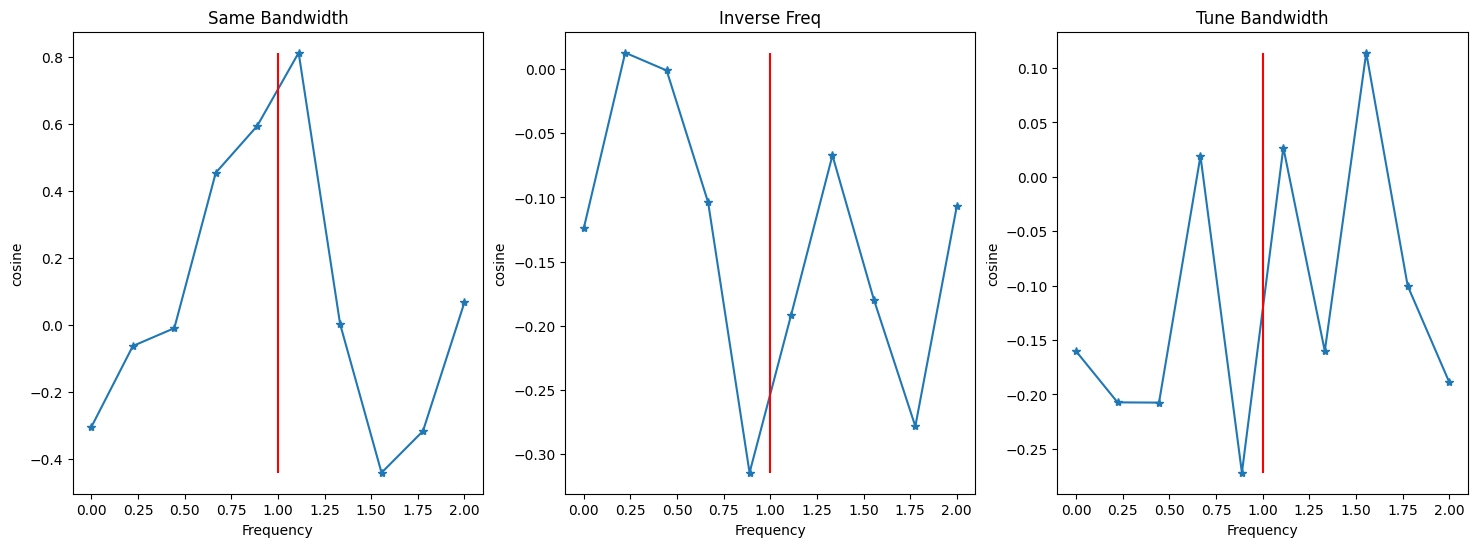

In [ ]:
# Create figures
cols = [i for i in df.columns if i not in ["frequency", "experiment"]]
for col in cols:
    experiments = df["experiment"].unique()
    fig, ax = plt.subplots(ncols=len(experiments), figsize=(18, 6))

    for i, exp_name in enumerate(experiments):
        ax[i].plot(df[df["experiment"]==exp_name]["frequency"], df[df["experiment"]==exp_name][col], "-*")
        ax[i].set_xlabel("Frequency")
        ax[i].set_ylabel(col)
        ax[i].set_title(exp_name)
        ax[i].vlines(1, df[df["experiment"]==exp_name][col].min(), df[df["experiment"]==exp_name][col].max(), color="red")

    plt.savefig(savefile + "/results_" + col + ".png")

# Clustering Regression Setting